In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WELFake_Dataset.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (72134, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']

First 5 rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Data types:
 Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object


Label counts:
 label
1    37106
0    35028
Name: count, dtype: int64


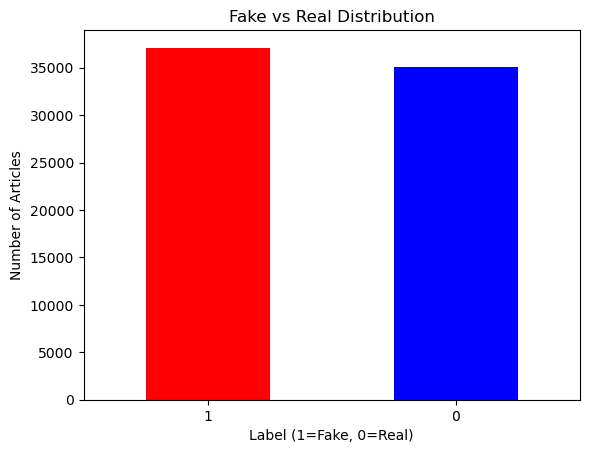

In [3]:
print("Label counts:\n", df['label'].value_counts())

df['label'].value_counts().plot(kind='bar', color=['red','blue'])
plt.title('Fake vs Real Distribution')
plt.xlabel('Label (1=Fake, 0=Real)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.show()

In [4]:
# Drop rows where text is missing
df = df.dropna(subset=['text'])

# Fill missing titles with empty string
df['title'] = df['title'].fillna('')

# Combine title + text for richer features
df['combined'] = df['title'] + ' ' + df['text']

print("Shape after fix:", df.shape)
print("Nulls remaining:\n", df.isnull().sum())

Shape after fix: (72095, 5)
Nulls remaining:
 Unnamed: 0    0
title         0
text          0
label         0
combined      0
dtype: int64


In [5]:
# Cap text at 2000 words to avoid memory issues during training
df['combined'] = df['combined'].apply(lambda x: ' '.join(x.split()[:2000]))

# Save
df[['combined', 'label']].to_csv('../data/raw_combined.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [6]:
import sys
sys.path.append('../')
from preprocessing.text_cleaner import clean_text

# Test on one sample
sample = df['combined'].iloc[0]
print("BEFORE CLEANING:")
print(sample[:300])
print("\nAFTER CLEANING:")
print(clean_text(sample)[:300])

BEFORE CLEANING:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cop

AFTER CLEANING:
law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white people cop encouraged others radio show tuesday night turn tide kill white people cop send message kil


In [7]:
print("Cleaning text... this will take 1-2 minutes")

df['cleaned_text'] = df['combined'].apply(clean_text)

print("Done!")
print("\nSample cleaned text:")
print(df['cleaned_text'].iloc[0][:200])

Cleaning text... this will take 1-2 minutes
Done!

Sample cleaned text:
law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white pe


In [8]:
df[['cleaned_text', 'label']].to_csv('../data/cleaned_data.csv', index=False)
print("Cleaned dataset saved to data/cleaned_data.csv")
print("Final shape:", df[['cleaned_text', 'label']].shape)

Cleaned dataset saved to data/cleaned_data.csv
Final shape: (72095, 2)


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

# Drop any nulls that may have appeared after cleaning
df = df.dropna(subset=['cleaned_text'])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], 
    df['label'], 
    test_size=0.2,       # 80% train, 20% test
    random_state=42      # fixed seed so results are reproducible
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 57628
Testing samples: 14407


In [10]:
import sys
sys.path.append('../')
from feature_engineering.vectorizer import (
    build_tfidf_vectorizer, 
    transform_text, 
    save_vectorizer
)

# Build vectorizer on training data only
# IMPORTANT: never fit on test data — that would be cheating
tfidf = build_tfidf_vectorizer(X_train)

# Transform both train and test
X_train_tfidf = transform_text(tfidf, X_train)
X_test_tfidf = transform_text(tfidf, X_test)

# Save vectorizer for later use
save_vectorizer(tfidf)

print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)

Vectorizer saved to ../models/tfidf_vectorizer.pkl
Train matrix shape: (57628, 50000)
Test matrix shape: (14407, 50000)
